In [4]:
from src import *
from myutils import *
import gc

In [5]:
np.sign(0)

0

In [3]:
lst = np.linspace(0.1, 0.4, 61)

In [3]:
for m in ('di', ):

    root = lambda x: os.path.join(f'__raw__/20241116/{m}_5px', x)

    for _f in tqdm(lst):
        f = np.round(_f, 5)

        raw = np.load(root(f'{m}_5px_f{f}_d0_raw.npy'))
        timestamp = np.load(root(f'{m}_5px_f{f}_d0_timestamp.npy'))

        meta = MetaData(m.upper(), f, 3*DMD.PIXEL_SIZE/2, 0, timestamp)

        try:
            c = FrequencyEstimation.FromRaw(raw, meta)

            if not os.path.exists(f'__estimates__/{m}_5px'):
                os.makedirs(f'__estimates__/{m}_5px')

            c.savez(rf'__estimates__/{m}_5px')
            gc.collect()
        except:
            print(f'{m}_{f} not converged')


  0%|          | 0/61 [00:00<?, ?it/s]

100%|██████████| 61/61 [14:33<00:00, 14.32s/it]


In [32]:
c = LoadEstimates(r'__estimates__\di_5px_5\di_5px_f0.4_d0.npz')

c_ = Estimates(c.cropped_data, c.metadata, noise=c.noise)

In [33]:
# c__ = FrequencyEstimation.FromEstimates(c_)

In [74]:
pn_f_mean = []

for f in lst:

    c = LoadEstimates(rf'__estimates__\di_5px_5\di_5px_f{np.round(f, 5)}_d0.npz')
    pn_f = []

    for i in range(200):
        pn_f.append(freq_estimator(c.time_domain[i], method='fft'))

    pn_f_mean.append(np.mean(pn_f))

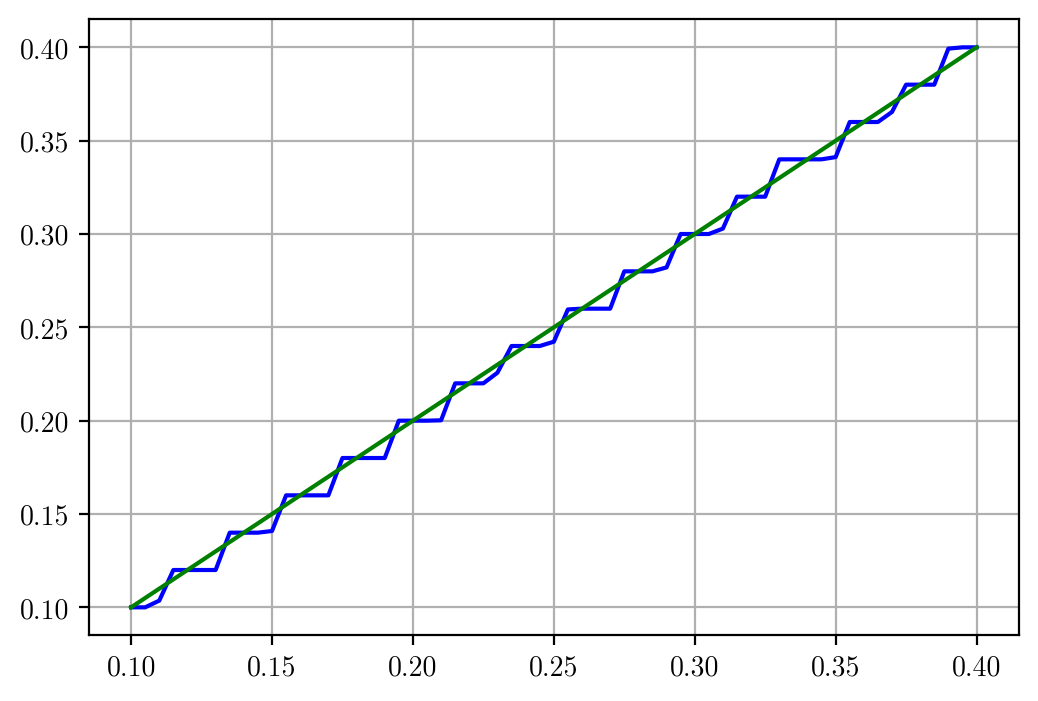

In [75]:
plot(lst, pn_f_mean)
plot(lst, lst)

In [117]:
c = LoadEstimates(rf'__estimates__\di_5px_5\di_5px_f0.135_d0.npz')
pn_f = []

pn_f.append(freq_estimator(c.time_domain.ravel(), method='fft'))
print(np.mean(pn_f))

0.14


In [118]:
len(c.time_domain.ravel())

10000

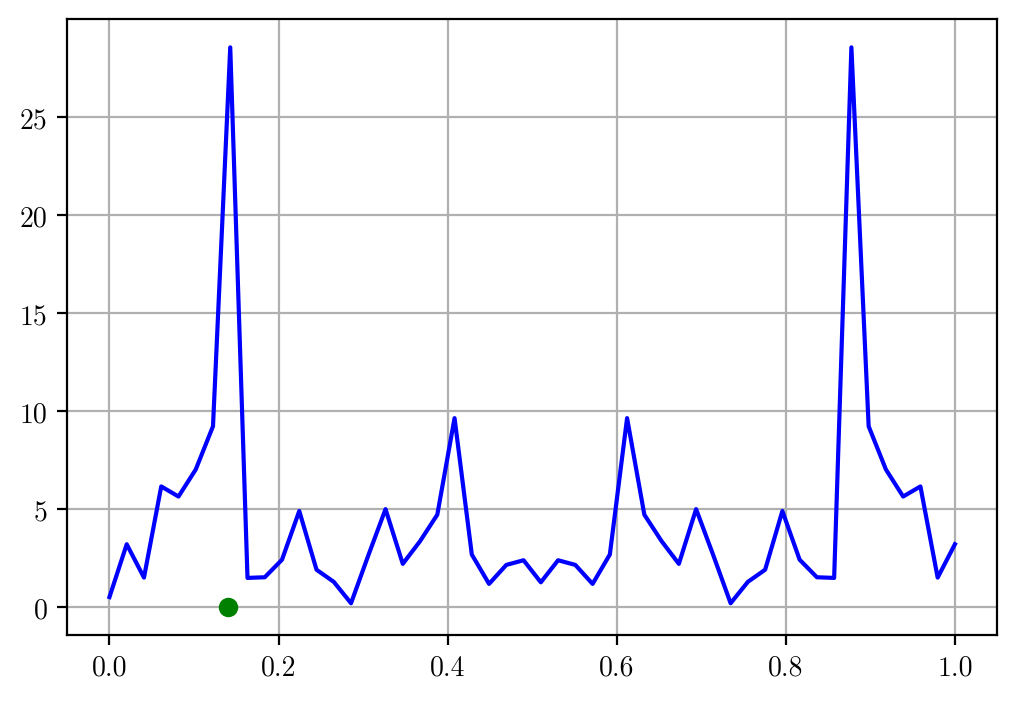

In [119]:
plot(np.linspace(0, 1, 50), abs_fft(c.time_domain[0]))
plot([0.14], [0], 'o')

In [96]:
0.138 in np.linspace(0, 1, 10000)

False

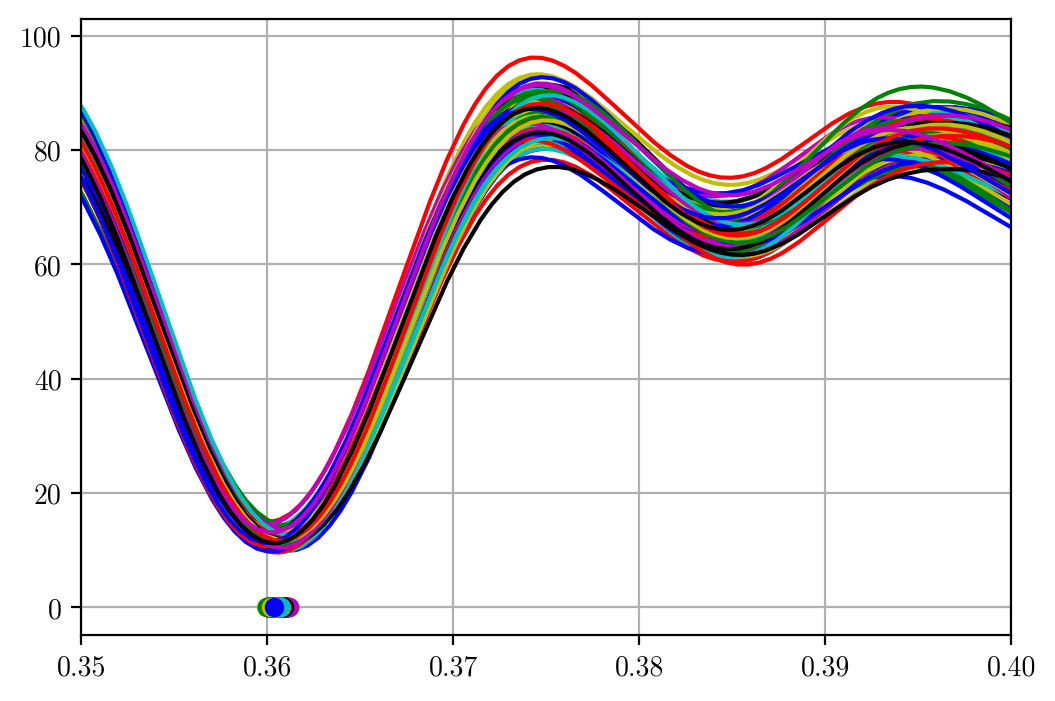

In [115]:

c = LoadEstimates(rf'__estimates__\di_5px_5\di_5px_f0.36_d0.npz')
for i in range(200):
    def waveform(f):
        n = np.arange(50)
        return np.sin(tau * f * n)

    def lsloss(f):
        
        return np.array([np.sum((c.time_domain[i] - waveform(_f))**2) for _f in f])

    plot(np.linspace(0.1, 0.4, 1000), lsloss(np.linspace(0.1, 0.4, 1000)))
    plot([c.frequency_estimates[i]], [0], 'o', xlim=(0.35, 0.4))